In [2]:
!pip install "dask[complete]" graphviz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00


In [3]:
!pip install "dask[complete]" --quiet
!pip install graphviz --quiet

import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar
import sys
import os
import pandas as pd
from IPython.display import Image

# Инициализация клиента Dask (Оптимизированные настройки без жесткого лимита памяти)
client = Client(n_workers=2, threads_per_worker=2, processes=True)
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:40099
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:39261'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:42449'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44081 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44081
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:56982
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:35139 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35139
INFO:distributed.core:Starting established connection to tcp://127

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 4,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40099,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44081,Total threads: 2
Dashboard: http://127.0.0.1:45189/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:39261,


In [4]:
import dask.dataframe as dd

# Определение типов данных для больших и неоднородных файлов NYC Parking
dtypes = {
    'Issuer Command': 'object',
    'Issuer Squad': 'object',
    'House Number': 'object',
    'Time First Observed': 'object',
    'Violation Description': 'object',
    'Violation Legal Code': 'object',
    'Violation Post Code': 'object',
    'Unregistered Vehicle?': 'float64',
    'Violation Location': 'float64',
    'Date First Observed': 'object',
    'Feet From Curb': 'float64',
    'Law Section': 'object',
    'Vehicle Year': 'float64',
    'Meter Number': 'object',
    'Violation County': 'object',
    'Double Parking Violation': 'object',
    'Hydrant Violation': 'object',
    'No Standing or Stopping Violation': 'object',
    'Sub Division': 'object',
    'Vehicle Color': 'object',
    'Vehicle Body Type': 'object',
    'Vehicle Make': 'object',
    'Violation Time': 'object'
}

df = dd.read_csv('/content/drive/MyDrive/Parking_Violations_Issued_-_Fiscal_Year_2015.csv', dtype=dtypes)
df

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Time First Observed,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Intersecting Street,Date First Observed,Law Section,Sub Division,Violation Legal Code,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
npartitions=44,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,string,string,string,string,int64,string,string,string,int64,int64,int64,string,float64,int64,int64,int64,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,float64,float64,string,float64,string,string,string,string,string,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [5]:
from dask.diagnostics import ProgressBar

# Подсчет пропущенных значений (построение графа вычислений)
missing_values = df.isnull().sum()

# Вычисление процента пропусков
mysize = df.index.size
missing_count = ((missing_values / mysize) * 100)

# Запуск реальных вычислений только для агрегированной статистики
with ProgressBar():
    missing_count_percent = missing_count.compute()

print(missing_count_percent.sort_values(ascending=False).head(15))

# Формирование списка столбцов, где пропусков > 55%
columns_to_drop = list(missing_count_percent[missing_count_percent > 55].index)
print("\nУдаляемые столбцы (пропуски > 55%):", columns_to_drop)

# Ленивое удаление столбцов
df_dropped = df.drop(columns=columns_to_drop)

# Удаление дополнительных технических и избыточных столбцов
additional_columns = [
    'Street Code1', 'Street Code2', 'Street Code3',
    'Issuer Code', 'Feet From Curb', 'Violation Post Code'
]

existing_extra = [c for c in additional_columns if c in df_dropped.columns]
df_final = df_dropped.drop(columns=existing_extra)

# Преобразование формата даты
df_final['Issue Date'] = dd.to_datetime(df_final['Issue Date'], errors='coerce')

df_final.head()

Community Board                      100.000000
Longitude                            100.000000
Latitude                             100.000000
NTA                                  100.000000
BBL                                  100.000000
BIN                                  100.000000
Census Tract                         100.000000
Community Council                    100.000000
Double Parking Violation              99.999992
Hydrant Violation                     99.999992
No Standing or Stopping Violation     99.999992
Time First Observed                   89.606065
Unregistered Vehicle?                 88.311519
Violation Legal Code                  84.883464
Meter Number                          80.833268
dtype: float64

Удаляемые столбцы (пропуски > 55%): ['Time First Observed', 'Intersecting Street', 'Violation Legal Code', 'Unregistered Vehicle?', 'Meter Number', 'No Standing or Stopping Violation', 'Hydrant Violation', 'Double Parking Violation', 'Latitude', 'Longitude', 'Comm

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Vehicle Expiration Date,...,Street Name,Date First Observed,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Violation Description
0,8002531292,EPC5238,NY,PAS,2014-10-01,21,SUBN,CHEVR,T,01/01/20150111 12:00:00 PM,...,Essex St,01/05/0001 12:00:00 PM,408,d1,Y Y Y,1200A,0300A,BL,2005.0,21-No Parking (street clean)
1,8015318440,5298MD,NY,COM,2015-03-06,14,VAN,FRUEH,T,01/01/88888888 12:00:00 PM,...,Park Ave,01/05/0001 12:00:00 PM,408,c,YYYYY,0700A,1000A,BROWN,0.0,14-No Standing
2,7611181981,FYW2775,NY,PAS,2014-07-28,46,SUBN,SUBAR,T,01/01/20160524 12:00:00 PM,...,31st St,01/05/0001 12:00:00 PM,408,f1,<NA>,<NA>,<NA>,BLACK,2010.0,46A-Double Parking (Non-COM)
3,7445908067,GWE1987,NY,PAS,2015-04-13,19,4DSD,LEXUS,T,01/01/20170111 12:00:00 PM,...,Queens Blvd,01/05/0001 12:00:00 PM,408,c3,YYYYY,0300P,1000P,GY,2015.0,19-No Stand (bus stop)
4,7037692864,T671196C,NY,PAS,2015-05-19,19,4DSD,CHRYS,T,01/01/88888888 12:00:00 PM,...,W 116th St,01/05/0001 12:00:00 PM,408,c3,YYYYYYY,<NA>,<NA>,BLACK,0.0,19-No Stand (bus stop)


In [6]:
df_final.to_csv('55_cleaned_violations_2015.csv',
                  single_file=True,
                  index=False)

['/content/55_cleaned_violations_2015.csv']

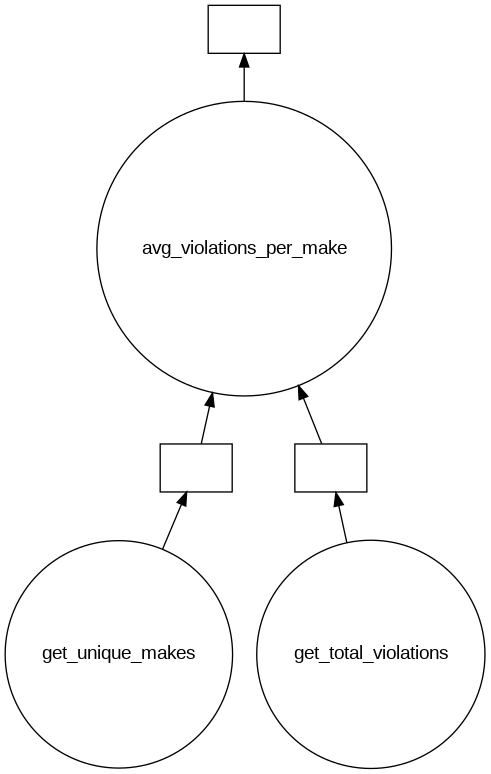

INFO:distributed.scheduler:Receive client connection: Client-worker-ef0becab-2a68-11f1-bce4-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:51496
INFO:distributed.scheduler:Receive client connection: Client-worker-ef0da274-2a68-11f1-bce6-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:51512


Результат вычисления DAG: 1690.9


In [7]:
from dask import delayed
from IPython.display import Image

def get_total_violations():
    return len(df_final)

def get_unique_makes():
    return df_final['Vehicle Make'].nunique().compute()

def avg_violations_per_make(total, unique):
    if unique == 0: return 0
    return round(total / unique, 2)

x = delayed(get_total_violations)()
y = delayed(get_unique_makes)()
z = delayed(avg_violations_per_make)(x, y)

try:
    z.visualize(filename='simple_violation_analysis.png')
    display(Image('simple_violation_analysis.png'))
except:
    print("Graphviz not found.")

print("Результат вычисления DAG:", z.compute())

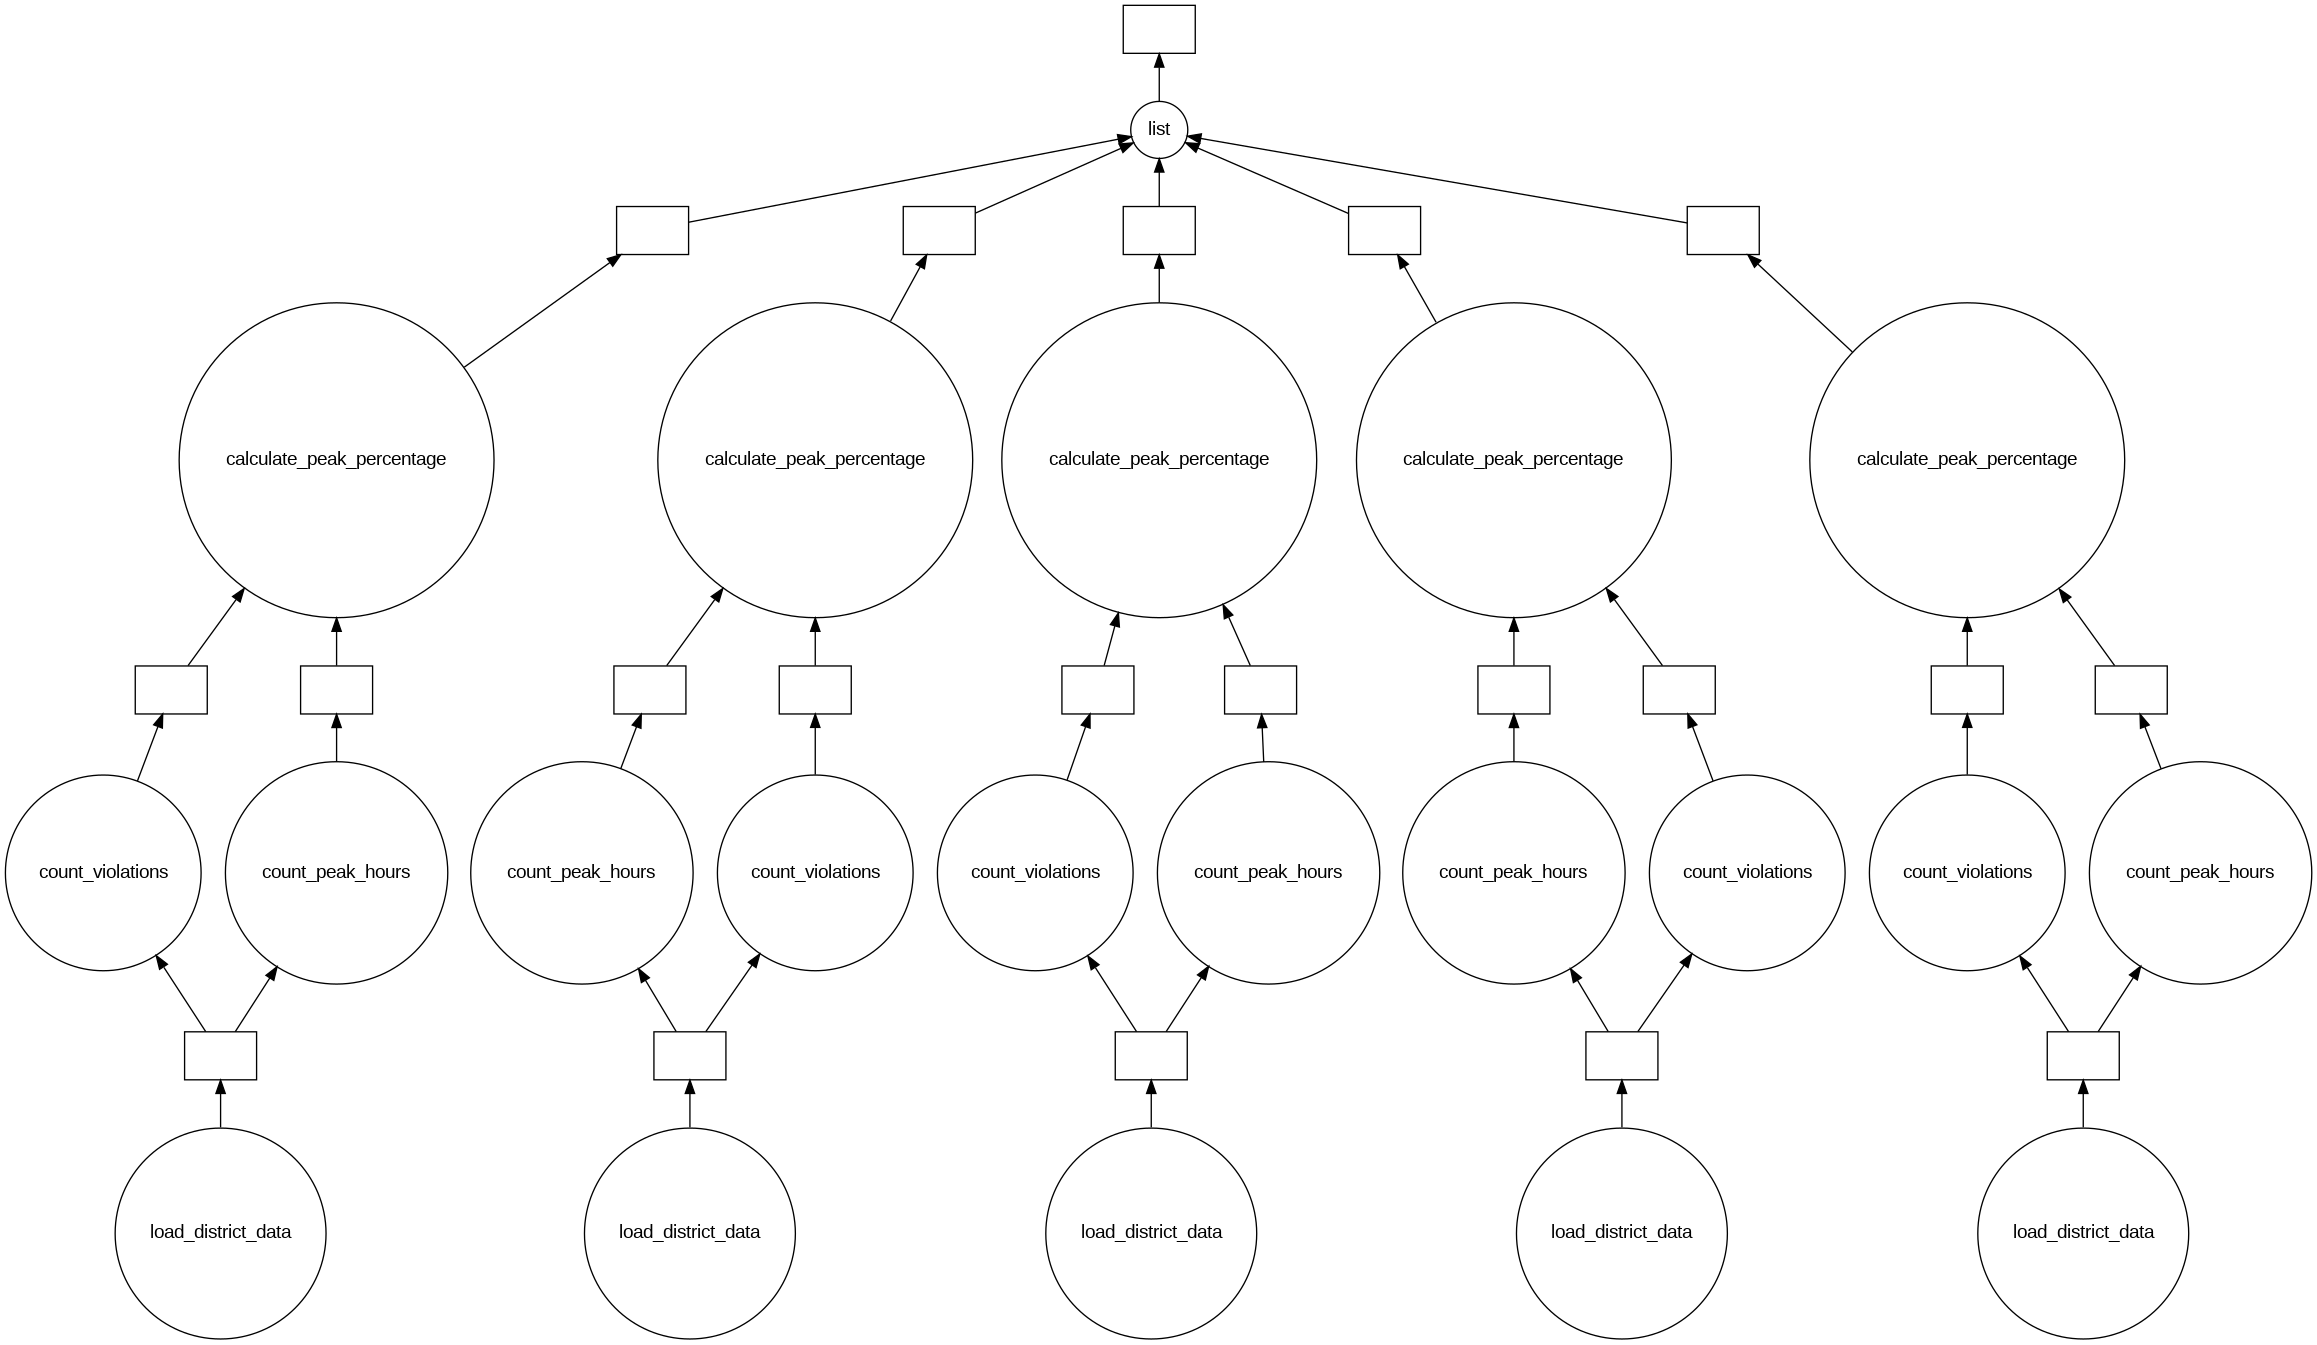

Результаты по районам % (NY, K, Q, BX, R): [32.73, 31.26, 31.8, 32.08, 34.7]


In [8]:
from dask import delayed
from IPython.display import Image

# Список районов для анализа
districts = ['NY', 'K', 'Q', 'BX', 'R']

def load_district_data(district):
    return df_final[df_final['Violation County'] == district]

def count_violations(district_data):
    return len(district_data)

def count_peak_hours(district_data):
    if district_data is None or len(district_data) == 0: return 0
    # Выделяем часы из Violation Time (первые 2 символа)
    hours = district_data['Violation Time'].astype(str).str[:2]
    peak = hours[hours.isin(['08', '09', '10'])]
    return len(peak)

def calculate_peak_percentage(total, peak):
    if total == 0: return 0
    return round((peak / total) * 100, 2)

layer1 = [delayed(load_district_data)(d) for d in districts]
layer2 = [delayed(count_violations)(d) for d in layer1]
layer3 = [delayed(count_peak_hours)(d) for d in layer1]
layer4 = [delayed(calculate_peak_percentage)(t, p) for t, p in zip(layer2, layer3)]

results = delayed(list)(layer4)

try:
    results.visualize(filename='complex_district_analysis.png')
    display(Image('complex_district_analysis.png'))
except:
    print("Graphviz error.")

print("Результаты по районам % (NY, K, Q, BX, R):", results.compute())

In [9]:
import pandas as pd
import altair as alt
from datetime import datetime
import re

# ========================
# 1. Загрузка и предобработка данных (только первые 20000 строк)
# ========================
df = pd.read_csv('/content/55_cleaned_violations_2015.csv',
                 parse_dates=['Issue Date'],
                 nrows=20000)

# Очистка дат (строки типа '01/05/0001' превращаются в NaT)
df['Issue Date'] = pd.to_datetime(df['Issue Date'], errors='coerce')
df = df.dropna(subset=['Issue Date'])

# Добавляем вспомогательные колонки
df['Issue Year'] = df['Issue Date'].dt.year
df['Issue Month'] = df['Issue Date'].dt.month
df['Issue DayOfWeek'] = df['Issue Date'].dt.day_name()
df['Issue Hour'] = df['Issue Date'].dt.hour

# Преобразование "From Hours In Effect" в часы (более гибкий парсинг)
def hour_from_str(s):
    if pd.isna(s) or s == '<NA>':
        return None
    s = str(s).strip()
    match = re.search(r'(\d{1,4})\s*([AP])', s, re.IGNORECASE)
    if not match:
        return None
    time_str = match.group(1).zfill(4)
    suffix = match.group(2).upper()
    try:
        hour = int(time_str[:2])
        minute = int(time_str[2:])
        if suffix == 'P' and hour != 12:
            hour += 12
        elif suffix == 'A' and hour == 12:
            hour = 0
        return hour
    except:
        return None

df['From Hour'] = df['From Hours In Effect'].apply(hour_from_str)

# Для графиков, использующих часы, убираем строки с отсутствующим часом
df_hour = df.dropna(subset=['From Hour'])

# Упорядочим дни недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# ========================
# 2. График 1: Топ-10 улиц по количеству нарушений
# ========================
street_counts = df['Street Name'].value_counts().reset_index()
street_counts.columns = ['Street Name', 'Count']
top_streets = street_counts.head(10).sort_values('Count', ascending=True)

chart1 = alt.Chart(top_streets).mark_bar().encode(
    x=alt.X('Count:Q', title='Количество нарушений'),
    y=alt.Y('Street Name:N', sort='-x', title='Улица'),
    color=alt.Color('Count:Q', scale=alt.Scale(scheme='viridis'), legend=None),
    tooltip=['Street Name', 'Count']
).properties(
    title='Топ-10 улиц с наибольшим количеством нарушений',
    width=600,
    height=400
)
chart1.save('top_streets.html')

# ========================
# 3. График 2: Распределение нарушений по дням недели
# ========================
chart2 = alt.Chart(df).mark_bar().encode(
    x=alt.X('Issue DayOfWeek:N', sort=day_order, title='День недели'),
    y=alt.Y('count():Q', title='Количество нарушений'),
    color=alt.Color('Issue DayOfWeek:N', scale=alt.Scale(scheme='set2'), legend=None),
    tooltip=['Issue DayOfWeek', 'count()']
).properties(
    title='Количество нарушений по дням недели',
    width=600,
    height=400
)
chart2.save('by_dayofweek.html')

# ========================
# 4. График 3: Распределение нарушений по часам (From Hours In Effect)
# ========================
chart3 = alt.Chart(df_hour).mark_bar().encode(
    x=alt.X('From Hour:Q', bin=alt.Bin(maxbins=24), title='Час начала действия запрета'),
    y=alt.Y('count():Q', title='Количество нарушений'),
    tooltip=['count()']
).properties(
    title='Распределение нарушений по часам',
    width=600,
    height=400
)
chart3.save('by_hour.html')

# ========================
# 5. График 4: Топ-10 марок автомобилей
# ========================
make_counts = df['Vehicle Make'].value_counts().reset_index()
make_counts.columns = ['Vehicle Make', 'Count']
top_makes = make_counts.head(10).sort_values('Count', ascending=True)

chart4 = alt.Chart(top_makes).mark_bar().encode(
    x=alt.X('Count:Q', title='Количество нарушений'),
    y=alt.Y('Vehicle Make:N', sort='-x', title='Марка автомобиля'),
    color=alt.Color('Count:Q', scale=alt.Scale(scheme='magma'), legend=None),
    tooltip=['Vehicle Make', 'Count']
).properties(
    title='Топ-10 марок автомобилей по количеству нарушений',
    width=600,
    height=400
)
chart4.save('top_makes.html')

# ========================
# 6. График 5: Топ-10 цветов автомобилей (исправлена схема на 'pastel1')
# ========================
color_counts = df['Vehicle Color'].value_counts().reset_index()
color_counts.columns = ['Vehicle Color', 'Count']
top_colors = color_counts.head(10).sort_values('Count', ascending=True)

chart5 = alt.Chart(top_colors).mark_bar().encode(
    x=alt.X('Count:Q', title='Количество нарушений'),
    y=alt.Y('Vehicle Color:N', sort='-x', title='Цвет автомобиля'),
    color=alt.Color('Count:Q', scale=alt.Scale(scheme='pastel1'), legend=None),
    tooltip=['Vehicle Color', 'Count']
).properties(
    title='Топ-10 цветов автомобилей среди нарушителей',
    width=600,
    height=400
)
chart5.save('top_colors.html')

# ========================
# 7. График 6: Временной ряд нарушений по месяцам
# ========================
monthly = df.groupby(pd.Grouper(key='Issue Date', freq='M')).size().reset_index(name='Count')
monthly['Month'] = monthly['Issue Date'].dt.strftime('%Y-%m')

chart6 = alt.Chart(monthly).mark_line(point=True).encode(
    x=alt.X('Month:N', title='Месяц', sort=monthly['Month'].tolist()),
    y=alt.Y('Count:Q', title='Количество нарушений'),
    tooltip=['Month', 'Count']
).properties(
    title='Динамика количества нарушений по месяцам',
    width=700,
    height=400
)
chart6.save('monthly_trend.html')

# ========================
# 8. График 7: Гистограмма года выпуска автомобиля
# ========================
current_year = datetime.now().year
df_year = df[(df['Vehicle Year'] > 1900) & (df['Vehicle Year'] <= current_year)]

chart7 = alt.Chart(df_year).mark_bar().encode(
    x=alt.X('Vehicle Year:Q', bin=alt.Bin(maxbins=50), title='Год выпуска'),
    y=alt.Y('count():Q', title='Количество нарушений'),
    tooltip=['count()']
).properties(
    title='Распределение годов выпуска автомобилей нарушителей',
    width=600,
    height=400
)
chart7.save('vehicle_year.html')

# ========================
# 9. График 8: Тепловая карта: день недели vs час
# ========================
heatmap_data = df_hour.groupby(['Issue DayOfWeek', 'From Hour']).size().reset_index(name='Count')
heatmap_data['Issue DayOfWeek'] = pd.Categorical(heatmap_data['Issue DayOfWeek'], categories=day_order, ordered=True)
heatmap_data = heatmap_data.sort_values(['Issue DayOfWeek', 'From Hour'])

chart8 = alt.Chart(heatmap_data).mark_rect().encode(
    x=alt.X('From Hour:O', title='Час начала действия запрета'),
    y=alt.Y('Issue DayOfWeek:N', sort=day_order, title='День недели'),
    color=alt.Color('Count:Q', scale=alt.Scale(scheme='yelloworangered'), title='Количество нарушений'),
    tooltip=['Issue DayOfWeek', 'From Hour', 'Count']
).properties(
    title='Тепловая карта нарушений: день недели и час',
    width=700,
    height=400
)
chart8.save('heatmap_day_hour.html')

print("Все графики сохранены в виде HTML-файлов")

/tmp/ipykernel_14752/3033354969.py:141: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.groupby(pd.Grouper(key='Issue Date', freq='M')).size().reset_index(name='Count')


Все графики сохранены в виде HTML-файлов
